# Pneumonia Detection — Chest X-Ray Classification (ConvNeXt CNN)

**Before running:** attach the chest X-ray dataset to this notebook.

1. Click **"+ Add Input"** in the top-right panel of the Kaggle notebook editor.
2. Search for **"Chest X-Ray Images (Pneumonia)"** (by *paultimothymooney*) and click **Add**.
3. Kaggle will mount it read-only under `/kaggle/input/chest-xray-pneumonia/...`.
4. Turn on a **GPU accelerator**: Settings (right panel) → Accelerator → **GPU T4 x2** (or P100).
5. Run all cells top to bottom (Run → Run All, or Ctrl+F9). The dataset path is detected automatically — no manual path editing needed.

Outputs (trained weights, checkpoints) are written to `/kaggle/working/outputs` and will appear in the notebook's **Output** tab once you **Save & Run All (Commit)**.

**Model:** This notebook uses **ConvNeXt-Tiny**, a modern, ImageNet-pretrained CNN architecture that adopts several design ideas from Vision Transformers (large kernel depthwise convolutions, LayerNorm, GELU, an inverted-bottleneck block) while remaining a pure convolutional network. It is generally faster to fine-tune than a ViT of comparable accuracy and tends to need less data to converge well, which suits a moderately-sized medical imaging dataset like this one.

In [22]:
# ── Install/upgrade required libraries (Kaggle already has torch + a CUDA build pre-installed,
#    so we only add/upgrade the extra packages this notebook needs) ─────────────────────────
!pip install -q -U transformers accelerate
!pip install -q pandas matplotlib seaborn scikit-learn pillow
print("Success! All packages installed.")

Success! All packages installed.


In [23]:
# NOTE: We do NOT reinstall torchvision here. Kaggle's GPU notebooks already ship
# a torch + torchvision pair that is matched to the container's CUDA version.
# Reinstalling torchvision from an external index can silently break GPU support.
import torchvision
import torch
print("torch version      :", torch.__version__)
print("torchvision version :", torchvision.__version__)
print("CUDA available      :", torch.cuda.is_available())

torch version      : 2.10.0+cu128
torchvision version : 0.25.0+cu128
CUDA available      : True


In [24]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as T
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
)

warnings.filterwarnings('ignore')

In [25]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"[INFO] GPU  : {torch.cuda.get_device_name(0)}")
    print(f"[INFO] VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

[INFO] Device: cuda
[INFO] GPU  : Tesla T4
[INFO] VRAM : 15.6 GB


In [26]:
import os

# ── Locate the dataset automatically under /kaggle/input ────────────
# Works with the popular "Chest X-Ray Images (Pneumonia)" dataset on Kaggle
# (https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia),
# regardless of whether Kaggle mounts it as .../chest_xray or .../chest_xray/chest_xray.

def find_dataset_root(search_root="/kaggle/input"):
    """Walk /kaggle/input looking for a folder that directly contains
    train/, val/ (or valid/), and test/ subfolders."""
    for dirpath, dirnames, _ in os.walk(search_root):
        lower = {d.lower() for d in dirnames}
        has_train = "train" in lower
        has_test  = "test" in lower
        has_val   = "val" in lower or "valid" in lower
        if has_train and has_test and has_val:
            return dirpath
    return None

BASE_DIR = find_dataset_root()

if BASE_DIR is None:
    raise FileNotFoundError(
        "❌ Could not find the dataset under /kaggle/input.\n"
        "   Make sure you've added the 'Chest X-Ray Images (Pneumonia)' dataset\n"
        "   to this notebook via Add Input (top-right panel) before running.\n"
        "   Expected a folder containing train/, val/ (or valid/), and test/ subfolders."
    )

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")
VAL_DIR   = os.path.join(BASE_DIR, "val") if os.path.isdir(os.path.join(BASE_DIR, "val")) \
            else os.path.join(BASE_DIR, "valid")

# Output path — Kaggle keeps everything written to /kaggle/working
OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, "best_pneumonia_cnn.pt")
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "pneumonia_cnn_checkpoint.pt")

MODEL_NAME = "convnext_tiny (torchvision, ImageNet-1k pretrained)"

# Quick sanity check
for d in [TRAIN_DIR, TEST_DIR, VAL_DIR]:
    assert os.path.isdir(d), f"❌ Directory not found: {d}"
print(f"✅ Dataset found at: {BASE_DIR}")
print(f"✅ All dataset directories found under {BASE_DIR}")

✅ Dataset found at: /kaggle/input/datasets/mgarg2005/chest-xray-hello/chest_xray
✅ All dataset directories found under /kaggle/input/datasets/mgarg2005/chest-xray-hello/chest_xray


In [27]:
def count_images(folder):
    return len([f for f in os.listdir(folder)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

num_pneu_train = count_images(os.path.join(TRAIN_DIR, 'PNEUMONIA'))
num_norm_train = count_images(os.path.join(TRAIN_DIR, 'NORMAL'))

print("Dataset Statistics")
print("=" * 44)
print(f"  Train  → PNEUMONIA: {num_pneu_train:>4}  |  NORMAL: {num_norm_train:>4}")
print(f"  Test   → PNEUMONIA: {count_images(os.path.join(TEST_DIR,'PNEUMONIA')):>4}  "
      f"|  NORMAL: {count_images(os.path.join(TEST_DIR,'NORMAL')):>4}")
print(f"  Val    → PNEUMONIA: {count_images(os.path.join(VAL_DIR,'PNEUMONIA')):>4}  "
      f"|  NORMAL: {count_images(os.path.join(VAL_DIR,'NORMAL')):>4}")
print(f"  Imbalance ratio   : {num_pneu_train/num_norm_train:.2f}:1")

Dataset Statistics
  Train  → PNEUMONIA: 3875  |  NORMAL: 1341
  Test   → PNEUMONIA:  390  |  NORMAL:  234
  Val    → PNEUMONIA:    8  |  NORMAL:    8
  Imbalance ratio   : 2.89:1


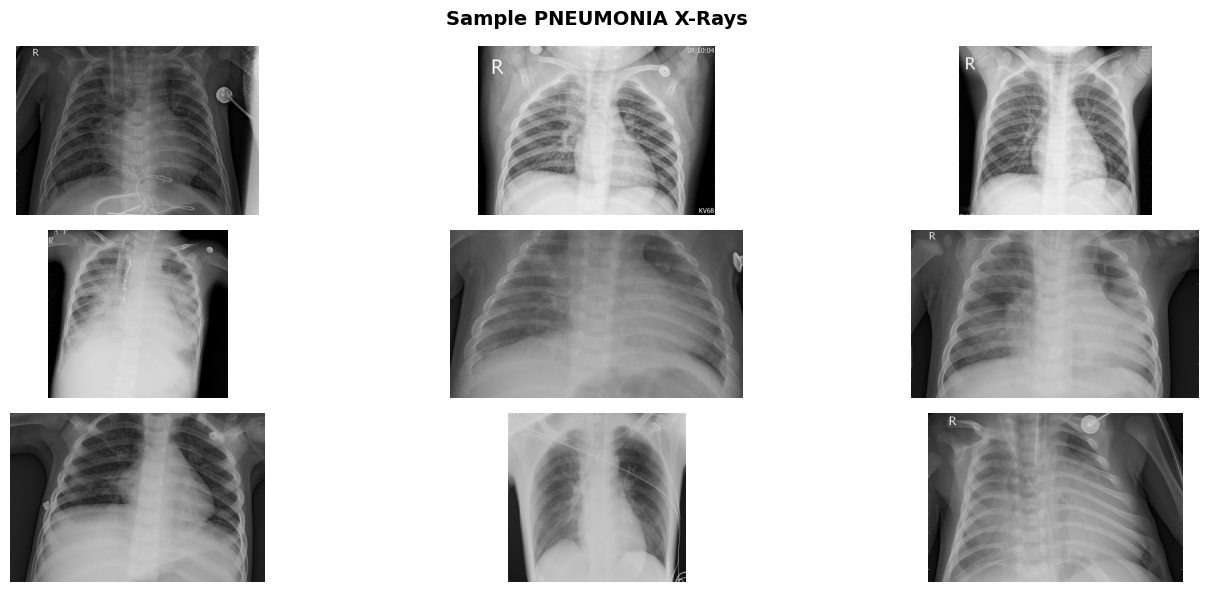

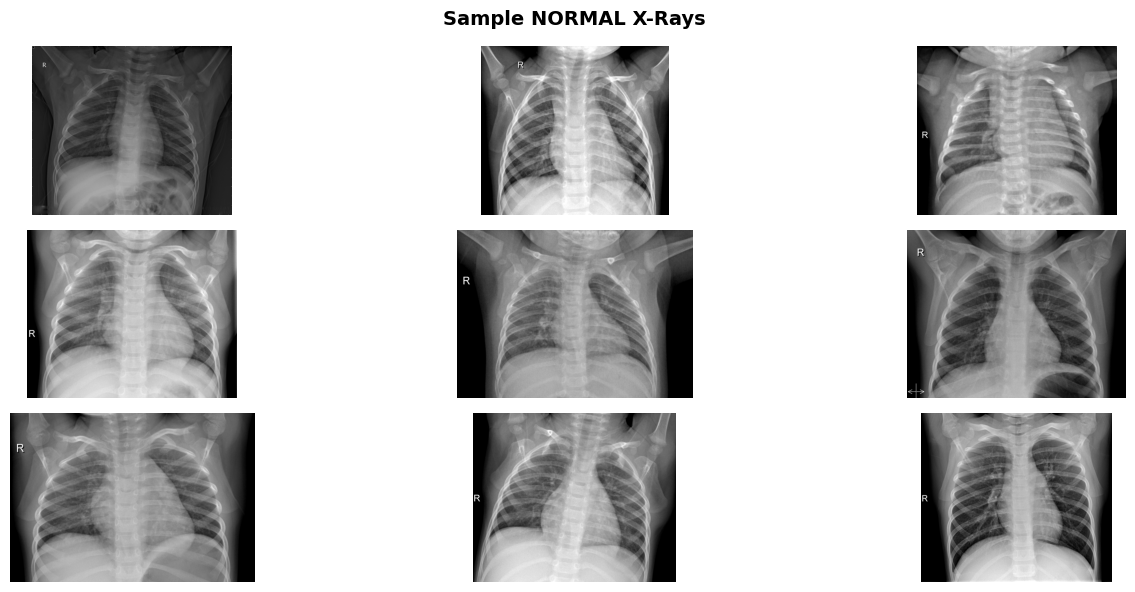

In [28]:
def show_sample_images(folder_path, title, n=9):
    files = [f for f in os.listdir(folder_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:n]
    plt.figure(figsize=(15, 6))
    plt.suptitle(title, fontsize=14, fontweight='bold')
    for i, fname in enumerate(files):
        plt.subplot(3, 3, i + 1)
        img = plt.imread(os.path.join(folder_path, fname))
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images(os.path.join(TRAIN_DIR, 'PNEUMONIA'), 'Sample PNEUMONIA X-Rays')
show_sample_images(os.path.join(TRAIN_DIR, 'NORMAL'),    'Sample NORMAL X-Rays')

In [29]:
print(f"[INFO] Using pretrained weights/preprocessing for '{MODEL_NAME}'…")

# ConvNeXt-Tiny (ImageNet-1k) expects 224x224 inputs normalized with standard
# ImageNet statistics. We pull the exact mean/std/size from the torchvision
# weight metadata so preprocessing always matches what the backbone was
# pretrained with.
_convnext_weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
_meta_transform    = _convnext_weights.transforms()

IMG_SIZE = 224
IMG_MEAN = list(_meta_transform.mean)   # [0.485, 0.456, 0.406]
IMG_STD  = list(_meta_transform.std)    # [0.229, 0.224, 0.225]

# ── Train augmentation ──────────────────────────────────────────────
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.RandomAutocontrast(p=0.3),
    T.ToTensor(),
    T.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

# ── Eval transform ──────────────────────────────────────────────────
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

print(f"[INFO] Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"[INFO] Mean: {IMG_MEAN}  |  Std: {IMG_STD}")

[INFO] Using pretrained weights/preprocessing for 'convnext_tiny (torchvision, ImageNet-1k pretrained)'…
[INFO] Image size: 224x224
[INFO] Mean: [0.485, 0.456, 0.406]  |  Std: [0.229, 0.224, 0.225]


In [30]:
class XRayDataset(Dataset):
    """Loads X-ray images. Labels: NORMAL=0, PNEUMONIA=1"""
    LABEL_MAP = {'NORMAL': 0, 'PNEUMONIA': 1}

    def __init__(self, root_dir=None, transform=None, samples=None):
        self.transform = transform
        if samples is not None:
            self.samples = samples          # pre-built (path, label) list
        else:
            self.samples = []
            for class_name, label in self.LABEL_MAP.items():
                class_dir = os.path.join(root_dir, class_name)
                if not os.path.isdir(class_dir):
                    continue
                for fname in os.listdir(class_dir):
                    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.samples.append((os.path.join(class_dir, fname), label))
            random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)

In [31]:
from sklearn.model_selection import train_test_split

BATCH_SIZE  = 32
NUM_WORKERS = 2

# VAL_DIR only has ~16 images -> unreliable metrics, so we ignore it and
# instead hold out a stratified slice of TRAIN_DIR for validation.
VAL_SPLIT = 0.15

all_train_samples = XRayDataset(TRAIN_DIR).samples
labels_for_split   = [label for _, label in all_train_samples]

train_samples, val_samples = train_test_split(
    all_train_samples,
    test_size=VAL_SPLIT,
    stratify=labels_for_split,
    random_state=SEED,
)

train_dataset = XRayDataset(samples=train_samples, transform=train_transform)
val_dataset   = XRayDataset(samples=val_samples,   transform=eval_transform)
test_dataset  = XRayDataset(TEST_DIR, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=True)

print(f"[INFO] Train: {len(train_dataset)}  |  Val: {len(val_dataset)}  "
      f"|  Test: {len(test_dataset)}")

[INFO] Train: 4433  |  Val: 783  |  Test: 624


In [32]:
total       = num_pneu_train + num_norm_train
w_normal    = total / (2.0 * num_norm_train)
w_pneumonia = total / (2.0 * num_pneu_train)
pos_weight  = torch.tensor([w_pneumonia / w_normal], dtype=torch.float32).to(DEVICE)

print(f"[INFO] Class weights → NORMAL: {w_normal:.3f}  |  PNEUMONIA: {w_pneumonia:.3f}")
print(f"[INFO] BCEWithLogitsLoss pos_weight: {pos_weight.item():.3f}")

[INFO] Class weights → NORMAL: 1.945  |  PNEUMONIA: 0.673
[INFO] BCEWithLogitsLoss pos_weight: 0.346


In [33]:
print(f"[INFO] Loading ConvNeXt-Tiny (CNN) backbone, ImageNet-1k pretrained…")
model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

# ConvNeXt's classification head is: Sequential(LayerNorm2d, Flatten, Linear(768, 1000)).
# We keep the LayerNorm2d + Flatten (they match the backbone's output feature map)
# and swap only the final Linear for a 3-layer MLP head, mirroring the ViT head
# design (same hidden sizes/dropout) so the two runs stay comparable.
in_features = model.classifier[2].in_features   # 768 for convnext_tiny

model.classifier[2] = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.GELU(),
    nn.Dropout(0.4),
    nn.Linear(256, 64),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(64, 1),
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[INFO] Total params    : {total_params:,}")
print(f"[INFO] Trainable params: {trainable_params:,}")

[INFO] Loading ConvNeXt-Tiny (CNN) backbone, ImageNet-1k pretrained…
[INFO] Total params    : 28,033,505
[INFO] Trainable params: 28,033,505


In [34]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ── Freeze / Unfreeze helpers ────────────────────────────────────────
def freeze_cnn_backbone(model):
    for name, param in model.named_parameters():
        param.requires_grad = 'classifier' in name
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[PHASE 1] Backbone frozen. Trainable params: {n:,} (head only)")

def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[PHASE 2] All layers unfrozen. Trainable params: {n:,}")

# ── Single epoch runner ──────────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer=None,
              train=True, threshold=0.5, scheduler=None):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = model(imgs).squeeze(1)
            loss   = criterion(logits, labels)

            if train and optimizer:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()   # step-level scheduler for Phase 2

            probs = torch.sigmoid(logits).detach().cpu().numpy()
            preds = (probs >= threshold).astype(int)
            lbls  = labels.detach().cpu().numpy().astype(int)

            total_loss += loss.item() * len(labels)
            correct    += (preds == lbls).sum()
            total      += len(labels)
            all_probs.extend(probs.tolist())
            all_labels.extend(lbls.tolist())

    avg_loss = total_loss / total
    accuracy = correct / total
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = float('nan')
    return avg_loss, float(accuracy), auc, all_probs, all_labels

In [35]:
EPOCHS_PHASE1 = 5
PATIENCE      = 6
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, "best_pneumonia_cnn.pt")
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'train_auc':  [], 'val_auc':  [],
}
best_val_auc = 0.0
best_epoch   = 0

print("=" * 60)
print("PHASE 1 — Head warm-up (encoder frozen)")
print("=" * 60)
freeze_cnn_backbone(model)

optimizer_p1 = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=0.01
)
scheduler_p1 = CosineAnnealingLR(optimizer_p1, T_max=EPOCHS_PHASE1)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    tr_loss, tr_acc, tr_auc, _, _ = run_epoch(
        model, train_loader, criterion, optimizer_p1, train=True)
    vl_loss, vl_acc, vl_auc, _, _ = run_epoch(
        model, val_loader,   criterion, train=False)
    scheduler_p1.step()   # epoch-level

    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(vl_acc)
    history['train_auc'].append(tr_auc);   history['val_auc'].append(vl_auc)

    print(f"  Epoch {epoch:02d}/{EPOCHS_PHASE1} | "
          f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
          f"Acc {tr_acc:.3f}/{vl_acc:.3f} | "
          f"AUC {tr_auc:.3f}/{vl_auc:.3f}")

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        best_epoch = epoch
        print(f"    ✓ Saved (best val AUC: {best_val_auc:.4f})")

PHASE 1 — Head warm-up (encoder frozen)
[PHASE 1] Backbone frozen. Trainable params: 214,913 (head only)
  Epoch 01/5 | Loss 0.1292/0.0755 | Acc 0.901/0.925 | AUC 0.962/0.987
    ✓ Saved (best val AUC: 0.9873)
  Epoch 02/5 | Loss 0.0794/0.1103 | Acc 0.942/0.886 | AUC 0.985/0.990
    ✓ Saved (best val AUC: 0.9900)
  Epoch 03/5 | Loss 0.0679/0.0842 | Acc 0.946/0.912 | AUC 0.989/0.991
    ✓ Saved (best val AUC: 0.9905)
  Epoch 04/5 | Loss 0.0642/0.0719 | Acc 0.952/0.934 | AUC 0.990/0.992
    ✓ Saved (best val AUC: 0.9916)
  Epoch 05/5 | Loss 0.0563/0.0845 | Acc 0.959/0.918 | AUC 0.992/0.992
    ✓ Saved (best val AUC: 0.9921)


In [36]:
print("=" * 60)
print("PHASE 2 — Full fine-tuning (last CNN stage + head)")
print("=" * 60)
for name, param in model.named_parameters():
    param.requires_grad = False
for name, param in model.named_parameters():
    # ConvNeXt-Tiny's `features` is a Sequential of 8 blocks: stem, stage1,
    # downsample, stage2, downsample, stage3, downsample, stage4 (index 7).
    # Unfreezing the last downsample + final stage (indices 6-7) is the CNN
    # analogue of unfreezing the last couple of ViT encoder layers.
    if "features.6" in name or "features.7" in name or "classifier" in name:
        param.requires_grad = True
EPOCHS_PHASE2 = 2
optimizer_p2 = AdamW([
    {'params': [p for n, p in model.named_parameters()
                if 'classifier' not in n], 'lr': 5e-6},   # CNN backbone: tiny LR
    {'params': model.classifier.parameters(),             # Head: larger LR
     'lr': 1e-4},
], weight_decay=0.01)

total_steps  = EPOCHS_PHASE2 * len(train_loader)
warmup_steps = total_steps // 10
scheduler_p2 = get_cosine_schedule_with_warmup(
    optimizer_p2,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

patience_ctr = 0

for epoch in range(1, EPOCHS_PHASE2 + 1):
    # Pass scheduler so run_epoch steps it after every batch
    tr_loss, tr_acc, tr_auc, _, _ = run_epoch(
        model, train_loader, criterion, optimizer_p2,
        train=True, threshold=0.5, scheduler=scheduler_p2)
    vl_loss, vl_acc, vl_auc, _, _ = run_epoch(
        model, val_loader, criterion, train=False, threshold=0.5)

    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(vl_acc)
    history['train_auc'].append(tr_auc);   history['val_auc'].append(vl_auc)

    improved = vl_auc > best_val_auc
    if improved:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        best_epoch   = EPOCHS_PHASE1 + epoch
        patience_ctr = 0
    else:
        patience_ctr += 1

    print(f"  Epoch {EPOCHS_PHASE1+epoch:02d} | "
          f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
          f"Acc {tr_acc:.3f}/{vl_acc:.3f} | "
          f"AUC {tr_auc:.3f}/{vl_auc:.3f}"
          + (" ✓" if improved else ""))

    if patience_ctr >= PATIENCE:
        print(f"\n[INFO] Early stopping triggered at epoch {EPOCHS_PHASE1+epoch}")
        break

print(f"\n[INFO] Best model from epoch {best_epoch} (val AUC = {best_val_auc:.4f})")    

PHASE 2 — Full fine-tuning (last CNN stage + head)
  Epoch 06 | Loss 0.0523/0.0643 | Acc 0.960/0.951 | AUC 0.994/0.992 ✓
  Epoch 07 | Loss 0.0504/0.0675 | Acc 0.963/0.945 | AUC 0.994/0.993 ✓

[INFO] Best model from epoch 7 (val AUC = 0.9926)


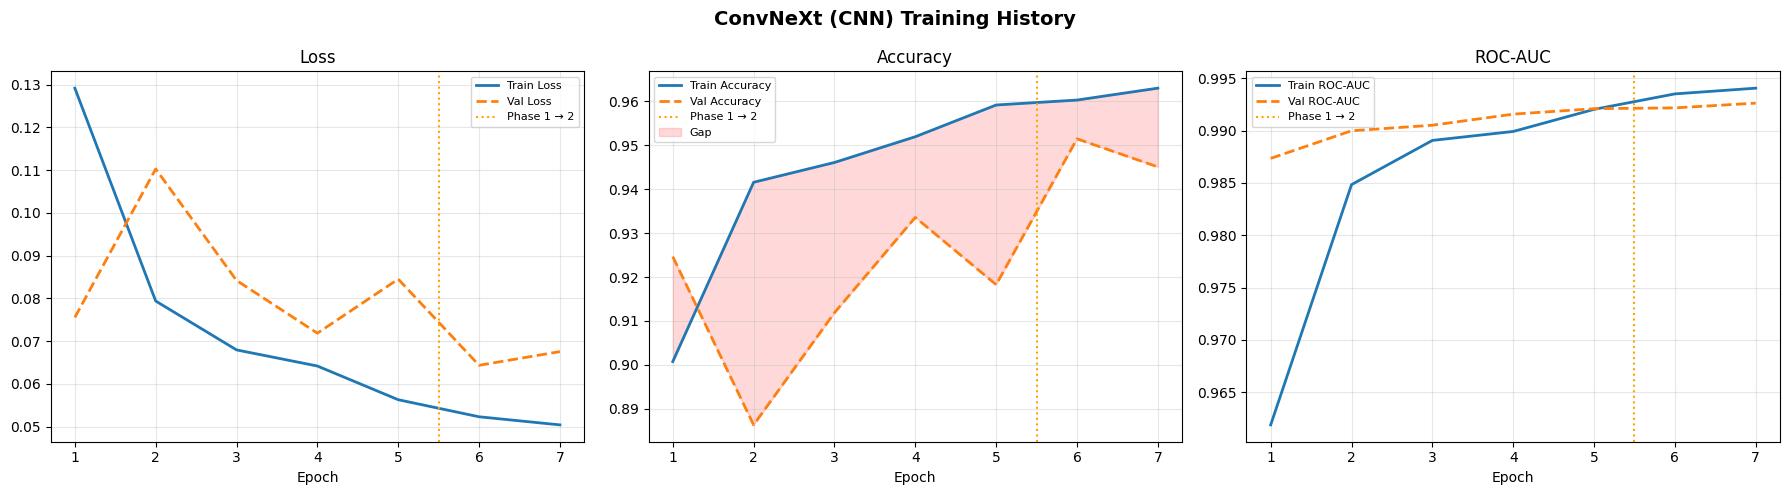


── Gap Analysis (best epoch = 7) ──
  Train acc : 0.9630  (96.3%)
  Val acc   : 0.9451  (94.5%)
  Gap       : 0.0179  (1.8%)
  ✓ < 5% — well generalised


In [37]:
def plot_history(h, phase1_epochs):
    ep  = range(1, len(h['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('ConvNeXt (CNN) Training History', fontsize=14, fontweight='bold')

    for ax, (tr_key, vl_key, title) in zip(axes, [
        ('train_loss', 'val_loss', 'Loss'),
        ('train_acc',  'val_acc',  'Accuracy'),
        ('train_auc',  'val_auc',  'ROC-AUC'),
    ]):
        ax.plot(ep, h[tr_key], label=f'Train {title}', lw=2)
        ax.plot(ep, h[vl_key], label=f'Val {title}',   lw=2, ls='--')
        ax.axvline(phase1_epochs + 0.5, color='orange', ls=':', lw=1.5,
                   label='Phase 1 → 2')
        if title == 'Accuracy':
            ax.fill_between(ep, h[vl_key], h[tr_key],
                            alpha=0.15, color='red', label='Gap')
        ax.set_title(title); ax.legend(fontsize=8)
        ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
    plt.show()

    best = int(np.argmax(h['val_auc']))
    tr_a = h['train_acc'][best]
    vl_a = h['val_acc'][best]
    gap  = tr_a - vl_a
    print(f"\n── Gap Analysis (best epoch = {best+1}) ──")
    print(f"  Train acc : {tr_a:.4f}  ({tr_a*100:.1f}%)")
    print(f"  Val acc   : {vl_a:.4f}  ({vl_a*100:.1f}%)")
    print(f"  Gap       : {gap:.4f}  ({gap*100:.1f}%)")
    print("  " + ("✓ < 5% — well generalised" if gap < 0.05
                  else "⚠ 5-10% — mild overfit" if gap < 0.10
                  else "✗ > 10% — overfit, increase dropout or L2"))

plot_history(history, EPOCHS_PHASE1)

In [38]:
print("[INFO] Loading best saved weights…")
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))

_, _, _, val_probs, val_labels = run_epoch(
    model, val_loader, criterion, train=False, threshold=0.5)
val_probs  = np.array(val_probs)
val_labels = np.array(val_labels)

precisions, recalls, thresholds = precision_recall_curve(val_labels, val_probs)
f1_scores = np.where(
    (precisions[:-1] + recalls[:-1]) > 0,
    2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1]),
    0
)
best_thresh_idx  = np.argmax(f1_scores)
chosen_threshold = float(thresholds[best_thresh_idx])

print(f"[INFO] Optimal threshold (max F1 on val): {chosen_threshold:.3f}")
print(f"       Precision: {precisions[best_thresh_idx]:.3f}  "
      f"Recall: {recalls[best_thresh_idx]:.3f}  "
      f"F1: {f1_scores[best_thresh_idx]:.3f}")

[INFO] Loading best saved weights…
[INFO] Optimal threshold (max F1 on val): 0.092
       Precision: 0.991  Recall: 0.966  F1: 0.978


In [39]:
print("── Test Set Evaluation ──────────────────────────")
_, test_acc, test_auc, test_probs, test_labels = run_epoch(
    model, test_loader, criterion, train=False, threshold=chosen_threshold)
test_probs  = np.array(test_probs)
test_labels = np.array(test_labels)

print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test ROC-AUC  : {test_auc:.4f}")

── Test Set Evaluation ──────────────────────────
  Test Accuracy : 85.58%
  Test ROC-AUC  : 0.9587



  Threshold = 0.5

Confusion Matrix:
[[189  45]
 [ 19 371]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.81      0.86       234
   PNEUMONIA       0.89      0.95      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624

  False Positive Rate (NORMAL → PNEUMONIA) : 19.23%
  False Negative Rate (PNEUMONIA → NORMAL) : 4.87%


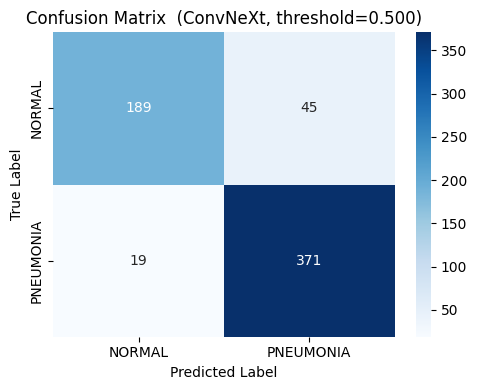


  Threshold = 0.092

Confusion Matrix:
[[147  87]
 [  3 387]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.63      0.77       234
   PNEUMONIA       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.81      0.83       624
weighted avg       0.88      0.86      0.85       624

  False Positive Rate (NORMAL → PNEUMONIA) : 37.18%
  False Negative Rate (PNEUMONIA → NORMAL) : 0.77%


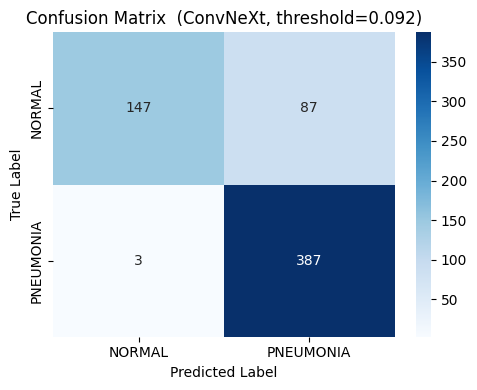

In [40]:
for thr in sorted({0.5, round(chosen_threshold, 3)}, reverse=True):
    preds  = (test_probs >= thr).astype(int)
    cm     = confusion_matrix(test_labels, preds)
    report = classification_report(test_labels, preds,
                                   target_names=['NORMAL', 'PNEUMONIA'])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    print(f"\n{'='*52}\n  Threshold = {thr}\n{'='*52}")
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nClassification Report:\n{report}")
    print(f"  False Positive Rate (NORMAL → PNEUMONIA) : {fpr:.2%}")
    print(f"  False Negative Rate (PNEUMONIA → NORMAL) : {fnr:.2%}")

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NORMAL', 'PNEUMONIA'],
                yticklabels=['NORMAL', 'PNEUMONIA'])
    plt.title(f'Confusion Matrix  (ConvNeXt, threshold={thr:.3f})')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'cm_thr_{str(thr).replace(".","_")}.png'), dpi=150)
    plt.show()

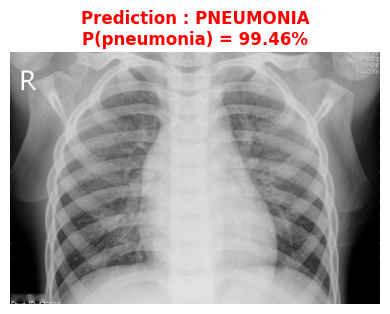

Predicted  : PNEUMONIA
Probability: 0.9946
Threshold  : 0.092


('PNEUMONIA', 0.9946162104606628)

In [41]:
def predict_single_image(image_path: str, threshold: float = None):
    if threshold is None:
        threshold = chosen_threshold

    img    = Image.open(image_path).convert("RGB")
    tensor = eval_transform(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logit = model(tensor).squeeze()
        prob  = torch.sigmoid(logit).item()

    label = 'PNEUMONIA' if prob >= threshold else 'NORMAL'
    color = 'red' if label == 'PNEUMONIA' else 'green'

    plt.figure(figsize=(4, 4))
    plt.imshow(np.array(img), cmap='gray')
    plt.axis('off')
    plt.title(f"Prediction : {label}\nP(pneumonia) = {prob:.2%}",
              fontsize=12, color=color, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Predicted  : {label}")
    print(f"Probability: {prob:.4f}")
    print(f"Threshold  : {threshold:.3f}")
    return label, prob

# ── Example: pick a random test image ────────────────────────────────
sample_img = os.path.join(TEST_DIR, 'PNEUMONIA',
             os.listdir(os.path.join(TEST_DIR, 'PNEUMONIA'))[0])
predict_single_image(sample_img)

In [42]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'model_name':       MODEL_NAME,
    'threshold':        chosen_threshold,
    'img_size':         IMG_SIZE,
    'img_mean':         IMG_MEAN,
    'img_std':          IMG_STD,
    'test_accuracy':    test_acc,
    'test_auc':         test_auc,
}
torch.save(checkpoint, CHECKPOINT_PATH)

print(f"\n[INFO] Full checkpoint saved → {CHECKPOINT_PATH}")
print(f"       Threshold: {chosen_threshold:.3f}")
print(f"       Test Acc : {test_acc*100:.2f}%")
print(f"       Test AUC : {test_auc:.4f}")
print(f"\n[INFO] Find outputs in {OUTPUT_DIR} → this persists in the notebook's Output tab after you Save & Run All / commit the Kaggle notebook.")


[INFO] Full checkpoint saved → /kaggle/working/outputs/pneumonia_cnn_checkpoint.pt
       Threshold: 0.092
       Test Acc : 85.58%
       Test AUC : 0.9587

[INFO] Find outputs in /kaggle/working/outputs → this persists in the notebook's Output tab after you Save & Run All / commit the Kaggle notebook.
